**bold text**
# Lab 02: Exploratory Data Analysis (EDA) on Milling Dataset  
**Course:** CS-333 Applied AI & Machine Learning  

---

## 📌 Instructions
- Perform each task under its respective section.
- Use separate cells for each step.
- Write explanations in Markdown cells.
- Ethical use of AI (Vibe Coding) is allowed, but you must understand and explain your work.


# **Name:** Syed Muhammad Subhan Waqi
# **Roll Number:** ME 1937
# **Section:** A

# 🔹 Task 1: Load the Dataset

In [133]:

# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns                       #visualisation
import matplotlib.pyplot as plt             #visualisation
%matplotlib inline
sns.set(color_codes=True)

# Dataset loaded from url without any issue
url = "https://raw.githubusercontent.com/AbbasHussain72/PNEC-CS-333-Applied-AI-ML/main/labs/Lab-02_/mill.csv"
df = pd.read_csv(url)
# To display the top 5 rows
df.head(5)

,S.no,Unnamed: 1,case,run,VB,time,DOC,feed,material,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
0,1,row_0,1,1,0.00,2,1.5,0.5,1,-0.017090,0.625000,0.078125,0.314941,0.087280,0.103760
1,2,row_1,1,2,NaN,4,1.5,0.5,1,0.307617,0.668945,0.075684,0.301514,0.086670,0.099487
2,3,row_2,1,3,NaN,6,1.5,0.5,1,-0.725098,0.913086,0.083008,0.295410,0.092773,0.104980
3,4,row_3,1,4,0.11,7,1.5,0.5,1,0.112305,0.131836,0.083008,0.316162,0.112915,0.139771
4,5,row_4,1,5,NaN,11,1.5,0.5,1,-0.122070,0.449219,0.107422,0.284424,0.095825,0.110474


In [134]:

# Display last 5 rows

df.tail(5)

,S.no,Unnamed: 1,case,run,VB,time,DOC,feed,material,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
175,176,row_164,16,4,NaN,4,1.50,0.50,2,0.244141,1.328125,0.063477,0.290527,0.101318,0.117798
176,177,row_165,16,5,0.40,6,1.50,0.50,2,-0.205078,1.381836,0.068359,0.289307,0.098877,0.114746
177,178,row_166,16,6,0.62,9,1.50,0.50,2,-0.380859,1.381836,0.041504,0.292969,0.075684,0.083008
178,179,row_153,14,10,1.14,24,0.75,0.50,2,0.253906,1.406250,0.083008,0.274658,0.092773,0.111084
179,180,row_154,15,1,NaN,1,1.50,0.25,2,-0.458984,1.357422,0.068359,0.292969,0.086060,0.104980


In [135]:

# Check data types

df.dtypes

,0
S.no,int64
Unnamed: 1,object
case,int64
run,int64
VB,float64
time,int64
DOC,float64
feed,float64
material,int64
smcAC,float64


In [136]:

# Check dataset shape

df.shape

(180, 15)

# 🔹 Task 2: Data Cleaning

In [137]:

# Check missing values

print(df.isnull().sum())

S.no            0
Unnamed: 1      0
case            0
run             0
VB             23
time            0
DOC             0
feed            0
material        0
smcAC           5
smcDC           1
vib_table       2
vib_spindle     4
AE_table        2
AE_spindle      1
dtype: int64


In [138]:
# Fill missing values --- 1

df = df.drop(columns=['Unnamed: 1'])
df = df.dropna(subset=['smcAC'])
df = df.dropna(subset=['smcDC'])
df = df.dropna(subset=['vib_table'])
df = df.dropna(subset=['vib_spindle'])
df = df.dropna(subset=['AE_table'])
df = df.dropna(subset=['AE_spindle'])


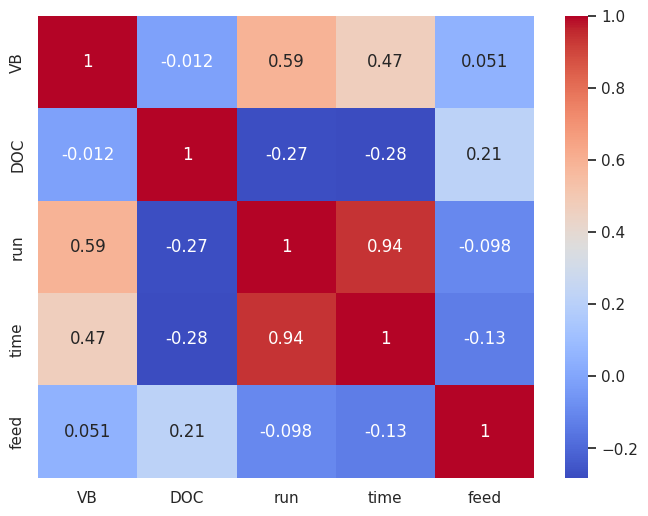

In [139]:
# Fill missing values --- 2

# Correlation with numeric features
# df[['VB','DOC','run','time','feed']].corr()  #for Table based output

plt.figure(figsize=(8,6))
sns.heatmap(df[['VB','DOC','run','time','feed']].corr(),
            annot=True, cmap='coolwarm')
plt.show()

In [140]:
# Fill missing values --- 3

df_no_missing_values = df.copy()

df_no_missing_values = df_no_missing_values.sort_values(by='run')

df_no_missing_values['VB_interp_run'] = df_no_missing_values['VB'].interpolate(method='linear')
df_no_missing_values['VB'] = df_no_missing_values['VB'].fillna(
    df_no_missing_values['VB_interp_run']
)
print(df_no_missing_values.isnull().sum())

df_no_missing_values = df_no_missing_values.sort_values(by='S.no')
df_no_missing_values.head(15)

S.no             0
case             0
run              0
VB               0
time             0
DOC              0
feed             0
material         0
smcAC            0
smcDC            0
vib_table        0
vib_spindle      0
AE_table         0
AE_spindle       0
VB_interp_run    0
dtype: int64


,S.no,case,run,VB,time,DOC,feed,material,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle,VB_interp_run
0,1,1,1,0.000,2,1.5,0.5,1,-0.017090,0.625000,0.078125,0.314941,0.087280,0.103760,0.000
1,2,1,2,0.115,4,1.5,0.5,1,0.307617,0.668945,0.075684,0.301514,0.086670,0.099487,0.115
2,3,1,3,0.210,6,1.5,0.5,1,-0.725098,0.913086,0.083008,0.295410,0.092773,0.104980,0.210
3,4,1,4,0.110,7,1.5,0.5,1,0.112305,0.131836,0.083008,0.316162,0.112915,0.139771,0.110
4,5,1,5,0.245,11,1.5,0.5,1,-0.122070,0.449219,0.107422,0.284424,0.095825,0.110474,0.245
5,6,1,6,0.200,15,1.5,0.5,1,0.329590,0.683594,0.070801,0.307617,0.103760,0.120239,0.200
6,7,1,7,0.240,19,1.5,0.5,1,-0.578613,1.381836,0.065918,0.322266,0.090942,0.123901,0.240
7,8,1,8,0.290,22,1.5,0.5,1,0.300293,1.435547,0.061035,0.308838,0.092773,0.108643,0.290
8,9,1,9,0.280,26,1.5,0.5,1,-0.305176,1.450195,0.065918,0.284424,0.084229,0.098877,0.280
10,11,1,11,0.380,32,1.5,0.5,1,-0.595703,1.381836,0.068359,0.301514,0.099487,0.120850,0.380


### ✍️ Explain how you handled missing values here.

The missing values in sensor-based features (smcAC, smcDC, vib_table, vib_spindle, AE_table, AE_spindle) were very small in number compared to the total dataset size (less than 1–2%).

Since these are continuous sensor signals and the missing entries are sparse, dropping those rows does not significantly impact the dataset distribution.

Therefore, row removal is a safer and statistically acceptable approach for such a small proportion of missing data.

Missing values in VB were replaced using linear interpolation based on run, which has the strongest correlation with tool wear.

Only missing entries were replaced, while original measured values were preserved to maintain data integrity.

In [141]:
# Check duplicates

duplicate_rows = df_no_missing_values[df_no_missing_values.duplicated()]

print("number of duplicate rows: ", duplicate_rows.shape)

number of duplicate rows:  (0, 15)


In [142]:
# Remove duplicates

df = df.drop_duplicates()

# 🔹 Task 3: Statistical Analysis

## 1️⃣ Center (Mean, Median, Mode)

In [143]:
print("Mean:\n", df_no_missing_values.mean())
print("\nMedian:\n", df_no_missing_values.median())
print("\nMode:\n", df_no_missing_values.mode())

Mean:
 S.no             89.572289
case              8.584337
run               7.192771
VB                0.324910
time             25.939759
DOC               1.034639
feed              0.370482
material          1.343373
smcAC            -0.165986
smcDC             1.345450
vib_table         0.079743
vib_spindle       0.286865
AE_table          0.101293
AE_spindle        0.124497
VB_interp_run     0.324910
dtype: float64

Median:
 S.no             88.500000
case             10.000000
run               6.000000
VB                0.260000
time             21.000000
DOC               0.750000
feed              0.250000
material          1.000000
smcAC            -0.184326
smcDC             1.376953
vib_table         0.068359
vib_spindle       0.285034
AE_table          0.101929
AE_spindle        0.122070
VB_interp_run     0.260000
dtype: float64

Mode:
      S.no  case  run   VB  time   DOC  feed  material     smcAC     smcDC  \
0       1  11.0  3.0  0.0   9.0  0.75  0.25       1.0  0.2

In [144]:
print("Column: VB")
print(f"  Mean: {df['VB'].mean()}")
print(f"  Median: {df['VB'].median()}")
print(f"  Modes: {df['VB'].mode().tolist()}")
print("----------------------------------")

Column: VB
  Mean: 0.33301369863013697
  Median: 0.28
  Modes: [0.0]
----------------------------------


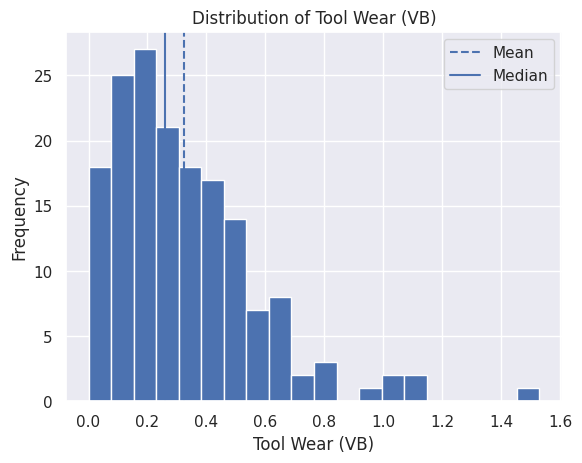

In [145]:
vb = df_no_missing_values['VB']

plt.figure()
plt.hist(vb, bins=20)
plt.axvline(vb.mean(), linestyle='--', label='Mean')
plt.axvline(vb.median(), linestyle='-', label='Median')
plt.xlabel('Tool Wear (VB)')
plt.ylabel('Frequency')
plt.title('Distribution of Tool Wear (VB)')
plt.legend()
plt.show()

### ✍️ Is tool wear normally distributed? Is mean close to median?
Since the mean lies to the right of the median, the distribution is positively skewed and not normally distributed.


##2️⃣ Spread (Variation)

In [146]:
df_sensors_only = df_no_missing_values.drop(['S.no', 'case', 'run', 'VB', 'time', 'DOC', 'feed', 'material', 'VB_interp_run'], axis=1)
df_sensors_only.head(5)

,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
0,-0.017090,0.625000,0.078125,0.314941,0.087280,0.103760
1,0.307617,0.668945,0.075684,0.301514,0.086670,0.099487
2,-0.725098,0.913086,0.083008,0.295410,0.092773,0.104980
3,0.112305,0.131836,0.083008,0.316162,0.112915,0.139771
4,-0.122070,0.449219,0.107422,0.284424,0.095825,0.110474


In [147]:
# Variance
variance = df_sensors_only.var()
variance

,0
smcAC,0.122860
smcDC,0.025229
vib_table,0.001307
vib_spindle,0.000408
AE_table,0.000508
AE_spindle,0.000356


In [148]:
# Range
range_values = df_sensors_only.max() - \
               df_sensors_only.min()

range_values


,0
smcAC,1.176758
smcDC,1.318359
vib_table,0.251465
vib_spindle,0.184326
AE_table,0.131836
AE_spindle,0.098267


In [149]:

# IQR
Q1 = df_sensors_only.quantile(0.25)
Q3 = df_sensors_only.quantile(0.75)

iqr = Q3 - Q1
iqr

,0
smcAC,0.728760
smcDC,0.042725
vib_table,0.021973
vib_spindle,0.021973
AE_table,0.021973
AE_spindle,0.026093


In [150]:
print("Highest Variance:", variance.idxmax())
print("Highest Range:", range_values.idxmax())
print("Highest IQR:", iqr.idxmax())

Highest Variance: smcAC
Highest Range: smcDC
Highest IQR: smcAC


### ✍️ Which sensor shows highest variability?

---

Variability of sensor signals was evaluated using three statistical measures:

- Variance
- Range
- IQR

Based on the computed results, smcAC shows the highest variability across all three metrics.

This indicates that this sensor experiences the largest fluctuations during the milling process, suggesting it may be more sensitive to changes in cutting conditions and tool wear.


## 3️⃣ Shape (Distribution)

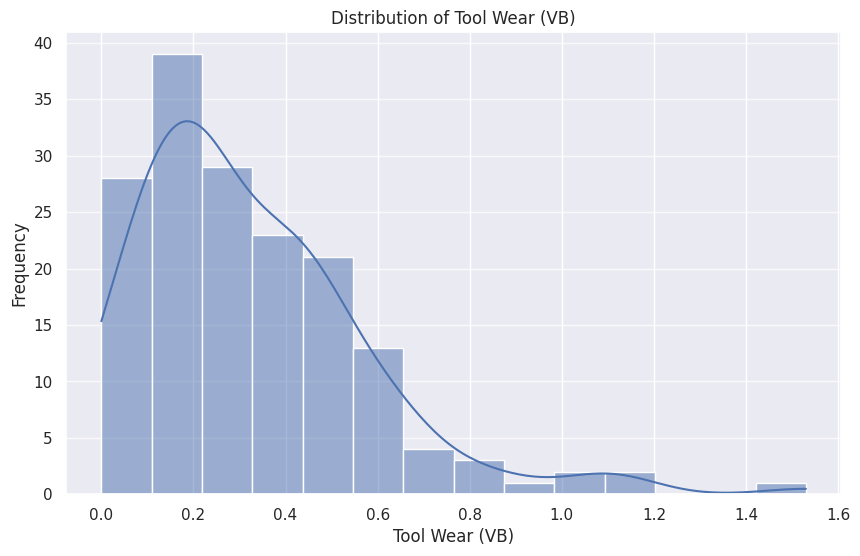

In [151]:

# Histogram of Tool Wear
plt.figure(figsize=(10, 6))
sns.histplot(df_no_missing_values['VB'], kde=True)
plt.title('Distribution of Tool Wear (VB)')
plt.xlabel('Tool Wear (VB)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


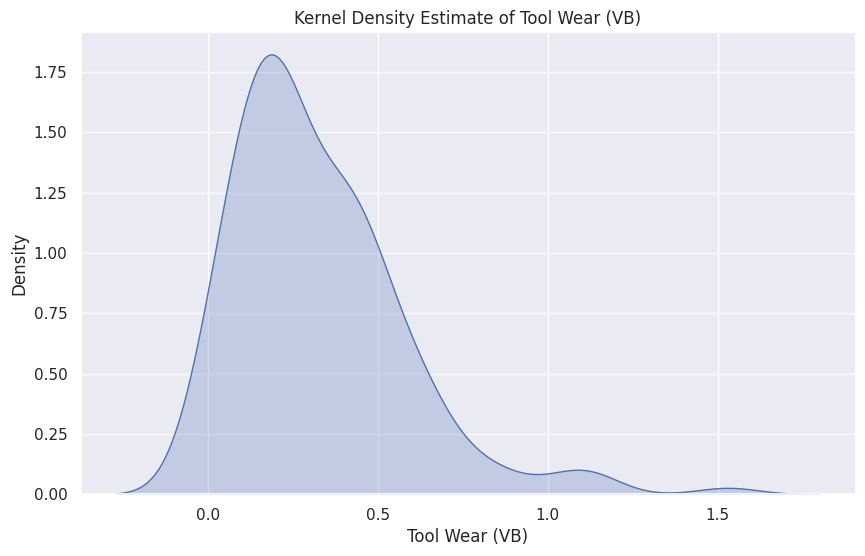

In [152]:

# KDE Plot

plt.figure(figsize=(10, 6))
sns.kdeplot(df_no_missing_values['VB'], fill=True)
plt.title('Kernel Density Estimate of Tool Wear (VB)')
plt.xlabel('Tool Wear (VB)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

### ✍️ Is distribution symmetric, skewed, or multi-modal?

Distribution is positively skewed

## 4️⃣ Outlier Detection

In [153]:
# Boxplot, IQR, Z-modified score
df_for_iqr = df_no_missing_values.drop(['S.no', 'case', 'material', 'VB_interp_run'], axis=1)
df_for_iqr.head(5)

,run,VB,time,DOC,feed,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
0,1,0.000,2,1.5,0.5,-0.017090,0.625000,0.078125,0.314941,0.087280,0.103760
1,2,0.115,4,1.5,0.5,0.307617,0.668945,0.075684,0.301514,0.086670,0.099487
2,3,0.210,6,1.5,0.5,-0.725098,0.913086,0.083008,0.295410,0.092773,0.104980
3,4,0.110,7,1.5,0.5,0.112305,0.131836,0.083008,0.316162,0.112915,0.139771
4,5,0.245,11,1.5,0.5,-0.122070,0.449219,0.107422,0.284424,0.095825,0.110474


In [154]:
# Stats of dataset before outliers are removed
before_stats = df_for_iqr.describe()
before_stats

,run,VB,time,DOC,feed,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
count,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000,166.000000
mean,7.192771,0.324910,25.939759,1.034639,0.370482,-0.165986,1.345450,0.079743,0.286865,0.101293,0.124497
std,4.759572,0.251551,22.340803,0.365051,0.125296,0.350514,0.158838,0.036147,0.020187,0.022536,0.018864
min,1.000000,0.000000,0.000000,0.750000,0.250000,-0.798340,0.131836,0.041504,0.207520,0.017700,0.083008
25%,3.000000,0.142500,9.000000,0.750000,0.250000,-0.533447,1.352539,0.061035,0.274658,0.092773,0.110474
50%,6.000000,0.260000,21.000000,0.750000,0.250000,-0.184326,1.376953,0.068359,0.285034,0.101929,0.122070
75%,10.000000,0.447500,39.000000,1.500000,0.500000,0.195312,1.395264,0.083008,0.296631,0.114746,0.136566
max,22.000000,1.530000,100.000000,1.500000,0.500000,0.378418,1.450195,0.292969,0.391846,0.149536,0.181274


In [155]:
Q1 = df_for_iqr.quantile(0.25)
Q3 = df_for_iqr.quantile(0.75)
IQR = Q3 - Q1

df_no_outliers = df_for_iqr[~((df_for_iqr < (Q1 - 1.5 * IQR)) | (df_for_iqr > (Q3 + 1.5 * IQR))).any(axis=1)]

df_no_outliers.shape

(125, 11)

In [156]:
# Stats of dataset after outliers are removed
after_stats = df_no_outliers.describe()
after_stats

,run,VB,time,DOC,feed,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
count,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,6.928000,0.306333,24.536000,1.044000,0.378000,-0.189766,1.375039,0.068848,0.285596,0.103975,0.123584
std,4.333247,0.200285,20.285281,0.367621,0.125467,0.339876,0.029907,0.014632,0.016044,0.014360,0.017763
min,1.000000,0.000000,0.000000,0.750000,0.250000,-0.751953,1.289062,0.041504,0.250244,0.075073,0.083008
25%,4.000000,0.140000,9.000000,0.750000,0.250000,-0.546875,1.352539,0.058594,0.274658,0.093994,0.110474
50%,6.000000,0.280000,19.000000,0.750000,0.500000,-0.200195,1.376953,0.065918,0.284424,0.101929,0.122070
75%,10.000000,0.440000,39.000000,1.500000,0.500000,0.161133,1.396484,0.075684,0.295410,0.114136,0.134888
max,19.000000,0.830000,80.000000,1.500000,0.500000,0.341797,1.450195,0.114746,0.322266,0.145264,0.171509


In [157]:
print("Rows before removal:", df_no_missing_values.shape[0])
print("Rows after removal:", df_no_outliers.shape[0])
print("Rows removed:", df_no_missing_values.shape[0] - df_no_outliers.shape[0])

Rows before removal: 166
Rows after removal: 125
Rows removed: 41



### ✍️
- Which method did you use (IQR or Modified Z-score)?

  IQR

- Why?
  It is robust to skewed distributions and does not assume normality, making it suitable for industrial sensor data.
  IQR was applied to continuous sensor and machining parameter columns such as, run, VB, time, DOC, feed, vibration, acoustic emission, and motor current, while identifier and categorical columns were excluded.

- How many outliers were removed?

  41

- How did it affect statistics?

  After removing outliers using IQR, the dataset count decreased from 166 to 127, indicating removal of extreme values. The standard deviation reduced significantly, showing less variability and more consistent data. The maximum values also decreased, confirming that extreme outliers were removed. The mean values slightly changed, indicating that outliers were influencing the average. Overall, outlier removal improved the quality and reliability of the dataset for analysis and machine learning.


# 🔹 Task 4: Correlation Analysis

,run,VB,time,DOC,feed,smcAC,smcDC,vib_table,vib_spindle,AE_table,AE_spindle
run,1.000000,0.576890,0.927162,-0.184042,0.020796,0.000300,0.384823,0.237802,-0.144198,-0.115160,-0.092191
VB,0.576890,1.000000,0.527497,0.166114,0.138171,-0.007246,0.239669,-0.083241,-0.228105,-0.056329,-0.075010
time,0.927162,0.527497,1.000000,-0.183516,0.017979,0.037792,0.347275,0.278840,-0.191537,0.026029,0.035268
DOC,-0.184042,0.166114,-0.183516,1.000000,0.128248,-0.053931,0.048911,-0.219068,0.146410,0.034792,-0.015558
feed,0.020796,0.138171,0.017979,0.128248,1.000000,0.117574,-0.010263,-0.087943,0.028804,0.003737,-0.020827
smcAC,0.000300,-0.007246,0.037792,-0.053931,0.117574,1.000000,0.263437,-0.086719,-0.080144,-0.098289,-0.097697
smcDC,0.384823,0.239669,0.347275,0.048911,-0.010263,0.263437,1.000000,0.099477,-0.042572,-0.153159,-0.134705
vib_table,0.237802,-0.083241,0.278840,-0.219068,-0.087943,-0.086719,0.099477,1.000000,-0.055182,0.182342,0.150125
vib_spindle,-0.144198,-0.228105,-0.191537,0.146410,0.028804,-0.080144,-0.042572,-0.055182,1.000000,-0.063510,-0.071799
AE_table,-0.115160,-0.056329,0.026029,0.034792,0.003737,-0.098289,-0.153159,0.182342,-0.063510,1.000000,0.957574


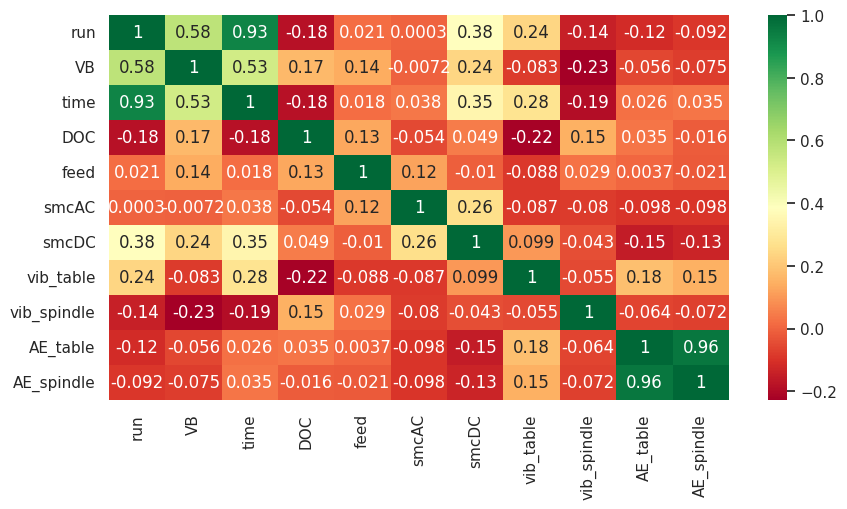

In [158]:
# Scatter Plot: Example (Tool Wear vs Vibration)
plt.figure(figsize=(10,5))
c= df_no_outliers.corr()
sns.heatmap(c,cmap="RdYlGn",annot=True)
c



### ✍️
  I used the dataset without outliers to ensure that the analysis reflects the true relationships between variables. Outliers can disproportionately influence statistical measures like correlation, potentially giving misleading insights. By working with the cleaned dataset, the resulting correlation matrix and heatmap provide a more accurate and representative view of how the variables interact under normal conditions.

- Does tool wear correlate strongly with vibration?

  No, since the relation between VB and Vibration of both, the spindle and the table are in negative.

- Which feature is most predictive?

  The acoustic emmision of table and spindle are most predictive with each other as their relation factor is 0.96


# 🔹 Task 5: Additional Visualization

Scatter Plot for Tool Wear vs Table Vibration:


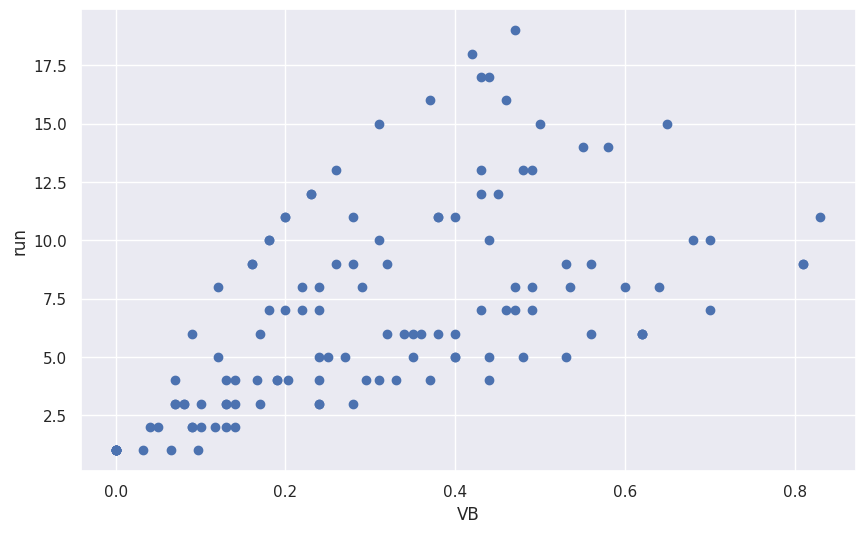

In [159]:
# Scatter plot showing relation of VB and run

fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(df_no_outliers['VB'], df_no_outliers['run'])
ax.set_xlabel('VB')
ax.set_ylabel('run')
print('Scatter Plot for Tool Wear vs Table Vibration:')
plt.show()




## 🧠 Engineering Thinking Questions
1. Which parameter affects tool wear the most?

2. Which sensor signal is most stable?

3. Can tool wear be predicted from sensor data?



Answers

### 1. Which parameter affects tool wear the most?

  According to the correlation matrix, the run parameter has the strongest positive linear correlation with VB (Tool Wear), with a coefficient of approximately 0.58. This indicates that run has the most significant linear influence on tool wear among the parameters analyzed.

### 2. Which sensor signal is most stable?

  The AE_table sensor is the most stable among the measured signals, as indicated by its low standard deviation of 0.014360. This small variability suggests that AE_table readings fluctuate minimally under the operating conditions, making it a reliable and consistent sensor for monitoring processes compared to the other signals in the dataset.

## 3. Can tool wear be predicted from sensor data?
  Tool wear cannot be reliably predicted from any single sensor signal based on linear correlation alone, but predictive modeling using multiple sensor inputs and advanced techniques is feasible.